# Ticket 1 — Data Collection & Exploratory Data Analysis
### Team 2 — GenAI Project: Disease Prediction + AI Recipe Recommendation
**Team Lead:** Milan TJ | **Contributors:** Nandana Venugopal, Sona Santhosh | **Sprint Deadline:** 02 Jul 2026

---
**Goal:** Collect, validate, and clean a symptom-to-disease dataset; perform exploratory data analysis; engineer NLP-based symptom features; and produce analysis-ready outputs for Ticket 2 (model development).

**Primary dataset:** [Disease Prediction Using Machine Learning](https://www.kaggle.com/datasets/kaushil268/disease-prediction-using-machine-learning) — 4,920 records, 132 binary symptom indicators, 41 disease labels (prognosis).

**Supplementary dataset:** [Disease Symptom Description Dataset](https://www.kaggle.com/datasets/itachi9604/disease-symptom-description-dataset) — adds disease descriptions, precautions, and symptom severity weights, used later to enrich the GenAI recipe/recommendation layer in Ticket 2/3.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

from pathlib import Path
import pandas as pd


BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR.parent / "data"


print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Collection
Two CSV files are loaded: `Training.csv` (4,920 records used for EDA and model training in Ticket 2) and `Testing.csv` (a small held-out validation set, 42 records, one per disease). Both come from the kaushil268 Kaggle dataset.


In [2]:
train_df = pd.read_csv(DATA_DIR / "Training.csv")
test_df = pd.read_csv(DATA_DIR / "Testing.csv")

print("Training set shape:", train_df.shape)
print("Testing set shape :", test_df.shape)
train_df.head()


Training set shape: (4920, 134)
Testing set shape : (42, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [3]:
# Supplementary lookup tables (itachi9604-style: descriptions, precautions, severity)
desc_df = pd.read_csv(DATA_DIR / "symptom_Description.csv")
prec_df = pd.read_csv(DATA_DIR / "symptom_precaution.csv")
sev_df = pd.read_csv(DATA_DIR / "Symptom-severity.csv")

print("Disease descriptions:", desc_df.shape)
print("Disease precautions :", prec_df.shape)
print("Symptom severities  :", sev_df.shape)
desc_df.head(3)

Disease descriptions: (41, 2)
Disease precautions : (41, 5)
Symptom severities  : (132, 2)


,Disease,Description
0,(vertigo) Paroymsal Positional Vertigo,A condition causing brief episodes of dizzines...
1,AIDS,"Acquired Immunodeficiency Syndrome, an advance..."
2,Acne,A skin condition occurring when hair follicles...


## 3. Dataset Schema Validation
Confirm column structure, data types, and check for an artifact trailing column that commonly appears in this dataset export.


In [4]:
print("Total columns:", train_df.shape[1])
print("Last 3 columns:", train_df.columns[-3:].tolist())
print()
print(train_df.dtypes.value_counts())

Total columns: 134
Last 3 columns: ['yellow_crust_ooze', 'prognosis', 'Unnamed: 133']

int64      132
str          1
float64      1
Name: count, dtype: int64


In [5]:
# The raw export contains a spurious fully-empty trailing column ('Unnamed: 133').
# This is a known artifact of the original CSV export and must be dropped.
unnamed_cols = [c for c in train_df.columns if 'Unnamed' in c]
print("Spurious columns found:", unnamed_cols)

train_df = train_df.drop(columns=unnamed_cols, errors='ignore')
test_df = test_df.drop(columns=[c for c in test_df.columns if 'Unnamed' in c], errors='ignore')

print("Training shape after drop:", train_df.shape)
print("Testing shape after drop :", test_df.shape)

Spurious columns found: ['Unnamed: 133']
Training shape after drop: (4920, 133)
Testing shape after drop : (42, 133)


In [6]:
symptom_cols = [c for c in train_df.columns if c != 'prognosis']
print(f"Symptom feature columns: {len(symptom_cols)}")
print(f"Target classes (diseases): {train_df['prognosis'].nunique()}")
print()
print("Disease list:")
for d in sorted(train_df['prognosis'].unique()):
    print(" -", d)


Symptom feature columns: 132
Target classes (diseases): 41

Disease list:
 - (vertigo) Paroymsal  Positional Vertigo
 - AIDS
 - Acne
 - Alcoholic hepatitis
 - Allergy
 - Arthritis
 - Bronchial Asthma
 - Cervical spondylosis
 - Chicken pox
 - Chronic cholestasis
 - Common Cold
 - Dengue
 - Diabetes 
 - Dimorphic hemmorhoids(piles)
 - Drug Reaction
 - Fungal infection
 - GERD
 - Gastroenteritis
 - Heart attack
 - Hepatitis B
 - Hepatitis C
 - Hepatitis D
 - Hepatitis E
 - Hypertension 
 - Hyperthyroidism
 - Hypoglycemia
 - Hypothyroidism
 - Impetigo
 - Jaundice
 - Malaria
 - Migraine
 - Osteoarthristis
 - Paralysis (brain hemorrhage)
 - Peptic ulcer diseae
 - Pneumonia
 - Psoriasis
 - Tuberculosis
 - Typhoid
 - Urinary tract infection
 - Varicose veins
 - hepatitis A


## 4. Data Cleaning

### 4.1 Missing Values


In [7]:
null_counts = train_df.isnull().sum()
print("Total missing values:", null_counts.sum())
print("Columns with missing values:", (null_counts > 0).sum())

Total missing values: 0
Columns with missing values: 0


No missing values remain after removing the spurious trailing column — the dataset is fully populated as binary 0/1 symptom indicators.

### 4.2 Duplicate Records

In [8]:
dup_count = train_df.duplicated().sum()
unique_count = train_df.drop_duplicates().shape[0]
print(f"Duplicate rows: {dup_count} out of {train_df.shape[0]} ({dup_count/train_df.shape[0]*100:.1f}%)")
print(f"Unique rows remaining after dedup: {unique_count}")
print()
print("Records per disease (raw):")
print(train_df['prognosis'].value_counts())

Duplicate rows: 4616 out of 4920 (93.8%)
Unique rows remaining after dedup: 304

Records per disease (raw):
prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                             

**Key finding:** the raw dataset has exactly 120 rows per disease (perfectly class-balanced at face value), but contains heavy duplication — only ~304 truly unique symptom-combinations exist across the 4,920 rows. This is a known characteristic of this dataset (confirmed by independent research/benchmarks on the same data) and is an important caveat for Ticket 2 model training: training on the full 4,920 rows mostly trains the model to recognize ~7 repeated symptom patterns per disease rather than diverse presentations.

**Decision:** We keep a `train_full` version (all 4,920 rows, matching the original Kaggle test/train split convention used in most reference implementations) **and** a `train_dedup` version (304 unique rows) — both saved to `/data/` for Ticket 2 to experiment with and compare model performance.


In [9]:
train_dedup = train_df.drop_duplicates().reset_index(drop=True)
print("Deduplicated shape:", train_dedup.shape)
print()
print("Records per disease (deduplicated):")
print(train_dedup['prognosis'].value_counts())

Deduplicated shape: (304, 133)

Records per disease (deduplicated):
prognosis
Migraine                                   10
Chicken pox                                10
Dengue                                     10
Hepatitis D                                10
Diabetes                                    9
Jaundice                                    9
Typhoid                                     9
hepatitis A                                 9
Hepatitis B                                 9
Hepatitis E                                 9
Tuberculosis                                9
Common Cold                                 9
Pneumonia                                   9
Hyperthyroidism                             9
Hypoglycemia                                9
Chronic cholestasis                         8
Malaria                                     8
Alcoholic hepatitis                         8
Varicose veins                              8
Hypothyroidism                              8
GE

### 4.3 Outlier Check
Since all 132 features are binary (0/1) symptom indicators, traditional numeric outlier detection (z-score/IQR) does not apply. Instead we check for invalid values outside {0,1}.

In [10]:
invalid_vals = train_df[symptom_cols].apply(lambda col: col[~col.isin([0,1])]).stack()
print("Invalid (non 0/1) values found:", len(invalid_vals))

Invalid (non 0/1) values found: 0


No invalid values found — all symptom columns are clean binary indicators.

## 5. Categorical Encoding
The target variable `prognosis` is label-encoded for downstream model training in Ticket 2. The encoder is saved so the same mapping can be reused for the test set and later inference in Ticket 3.


In [11]:
le = LabelEncoder()
train_df['prognosis_encoded'] = le.fit_transform(train_df['prognosis'])
test_df['prognosis_encoded'] = le.transform(test_df['prognosis'])
train_dedup['prognosis_encoded'] = le.transform(train_dedup['prognosis'])

mapping = pd.DataFrame({'disease': le.classes_, 'encoded_label': range(len(le.classes_))})
mapping.to_csv(DATA_DIR / "disease_label_mapping.csv", index=False)
print("Label mapping saved. Sample:")
mapping.head()


Label mapping saved. Sample:


,disease,encoded_label
0,(vertigo) Paroymsal Positional Vertigo,0
1,AIDS,1
2,Acne,2
3,Alcoholic hepatitis,3
4,Allergy,4


## 6. NLP Preprocessing — Symptom Keyword Extraction
Symptom column names use underscore-joined tokens (e.g. `burning_micturition`). We normalise these into clean, human-readable phrases — useful both for the word cloud below and later for the GenAI recipe prompt layer in Ticket 2/3, where natural-language symptom descriptions will be passed to the Gemini/OpenAI API.


In [12]:
def clean_symptom_name(s):
    s = s.strip().lower()
    s = re.sub(r'_+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

symptom_clean_map = {s: clean_symptom_name(s) for s in symptom_cols}
print("Sample symptom normalisation:")
for k in list(symptom_clean_map)[:8]:
    print(f"  {k!r:35s} -> {symptom_clean_map[k]!r}")


Sample symptom normalisation:
  'itching'                           -> 'itching'
  'skin_rash'                         -> 'skin rash'
  'nodal_skin_eruptions'              -> 'nodal skin eruptions'
  'continuous_sneezing'               -> 'continuous sneezing'
  'shivering'                         -> 'shivering'
  'chills'                            -> 'chills'
  'joint_pain'                        -> 'joint pain'
  'stomach_pain'                      -> 'stomach pain'


In [13]:
# Build a per-record natural-language symptom string (used for NLP-style EDA and
# as a template for future GenAI prompts: "patient reports: <symptom text>")
def row_to_symptom_text(row):
    present = [symptom_clean_map[s] for s in symptom_cols if row[s] == 1]
    return ', '.join(present)

train_df['symptom_text'] = train_df.apply(row_to_symptom_text, axis=1)
train_df[['prognosis', 'symptom_text']].head(3)

,prognosis,symptom_text
0,Fungal infection,"itching, skin rash, nodal skin eruptions, disc..."
1,Fungal infection,"skin rash, nodal skin eruptions, dischromic pa..."
2,Fungal infection,"itching, nodal skin eruptions, dischromic patches"


In [14]:
# Symptom frequency across the entire corpus (word-level) for keyword extraction
all_text = ' '.join(train_df['symptom_text'].tolist())
words = re.findall(r'[a-z]+', all_text)
word_freq = pd.Series(words).value_counts()
print("Top 20 most frequent symptom-related keywords:")
word_freq.head(20)

Top 20 most frequent symptom-related keywords:


pain         4254
of           3444
loss         2070
fatigue      1932
skin         1920
vomiting     1914
fever        1716
eyes         1386
high         1362
appetite     1272
nausea       1146
headache     1134
abdominal    1032
yellowish     912
urine         900
yellowing     816
muscle        816
chills        798
joint         798
itching       792
Name: count, dtype: int64

## 7. Exploratory Data Analysis
### 7.1 Disease Frequency Distribution

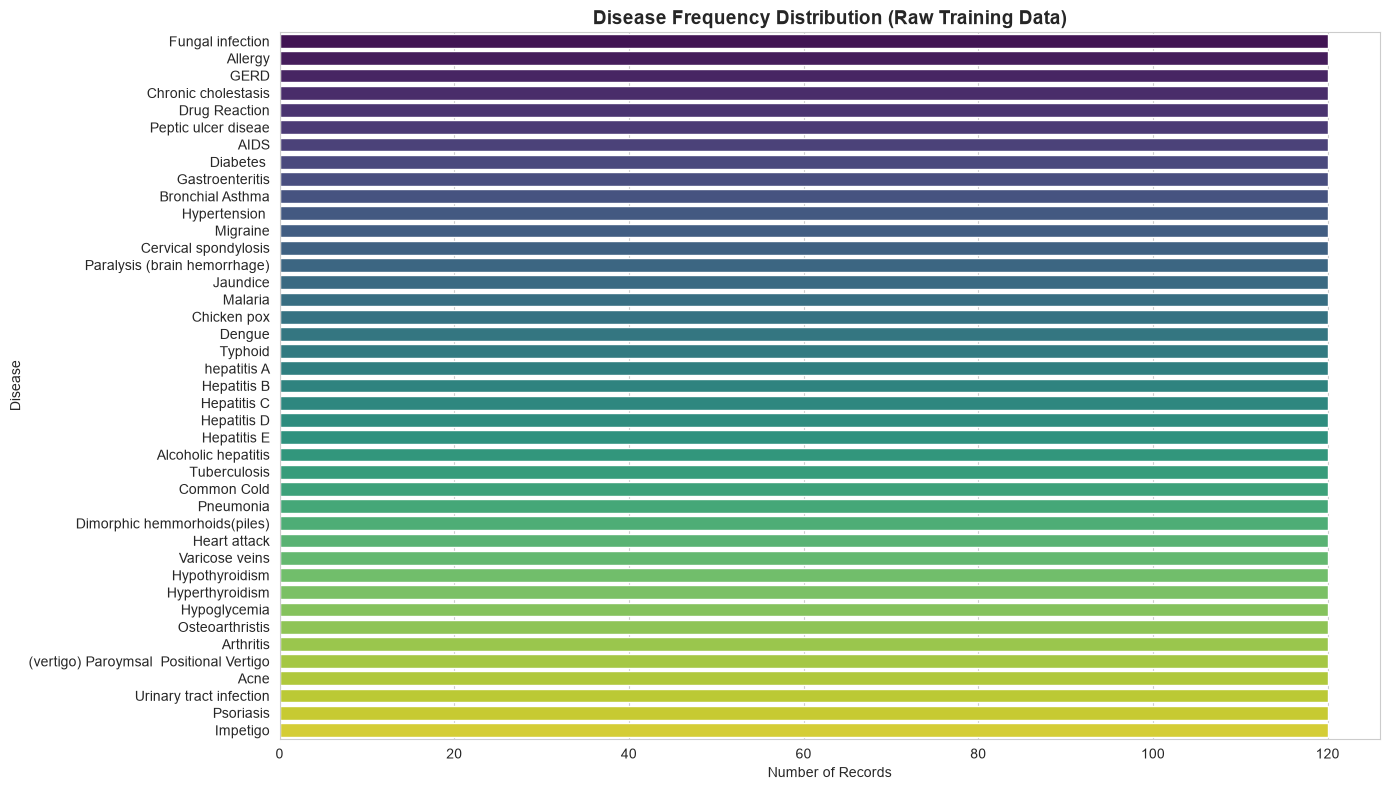

In [15]:
plt.figure(figsize=(14, 8))
order = train_df['prognosis'].value_counts().index
sns.countplot(y='prognosis', data=train_df, order=order, palette='viridis')
plt.title('Disease Frequency Distribution (Raw Training Data)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Records')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()


As established in the cleaning step, every disease has exactly 120 records — the bar chart confirms perfect class balance at the raw-row level.

### 7.2 Symptom Co-occurrence Heatmap
Correlation between symptom columns reveals which symptoms tend to appear together — useful for understanding feature redundancy ahead of Ticket 2 feature selection.

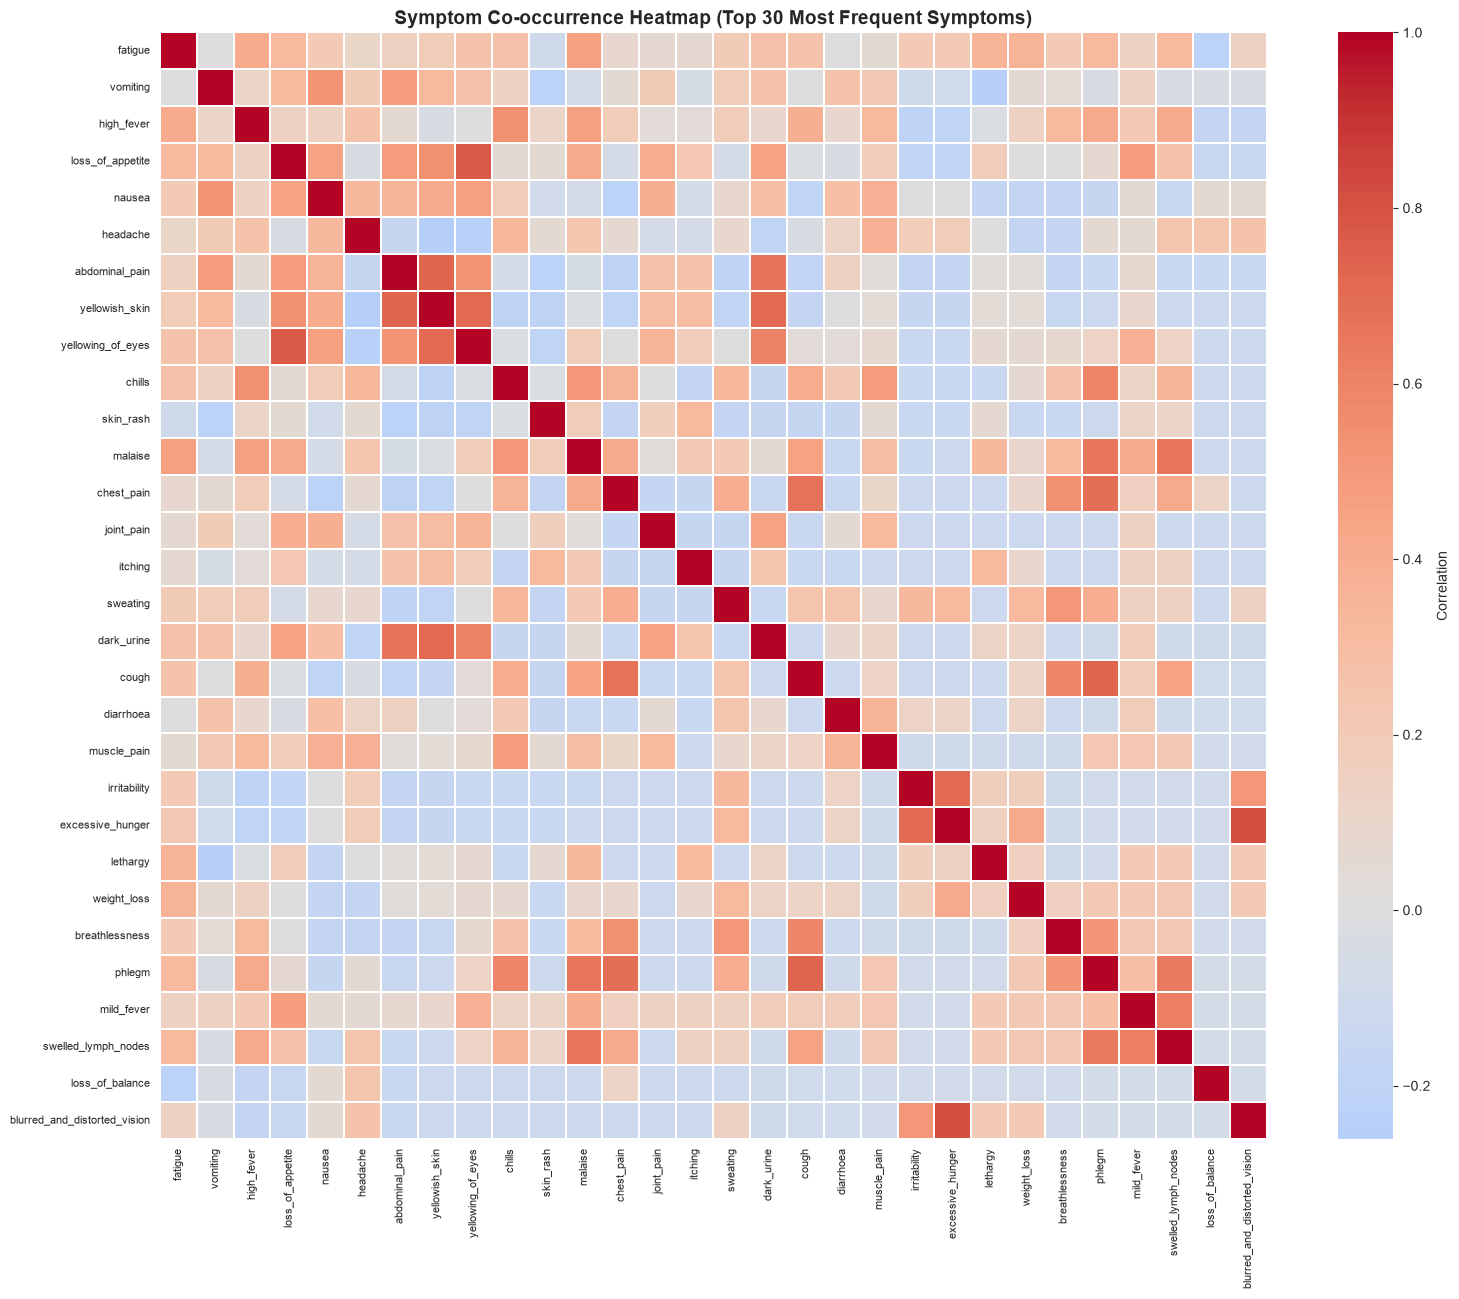

In [16]:
# Use a representative subset of the most frequent symptoms for a readable heatmap
top_symptoms = train_df[symptom_cols].sum().sort_values(ascending=False).head(30).index.tolist()
corr = train_df[top_symptoms].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=0.3,
            cbar_kws={'label': 'Correlation'})
plt.title('Symptom Co-occurrence Heatmap (Top 30 Most Frequent Symptoms)', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


### 7.3 Most Common Symptoms (Bar Chart)

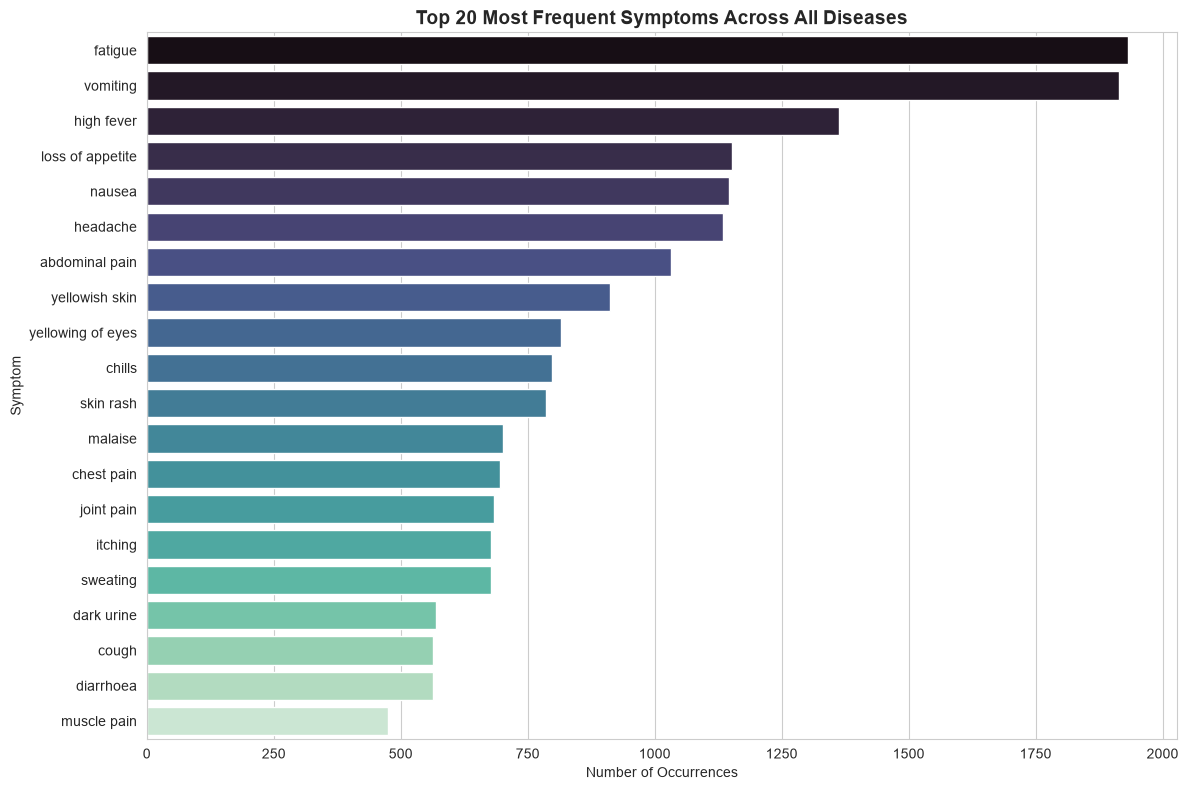

In [17]:
symptom_freq = train_df[symptom_cols].sum().sort_values(ascending=False).head(20)
symptom_freq.index = [symptom_clean_map[s] for s in symptom_freq.index]

plt.figure(figsize=(12, 8))
sns.barplot(x=symptom_freq.values, y=symptom_freq.index, palette='mako')
plt.title('Top 20 Most Frequent Symptoms Across All Diseases', fontsize=14, fontweight='bold')
plt.xlabel('Number of Occurrences')
plt.ylabel('Symptom')
plt.tight_layout()
plt.show()


### 7.4 Disease Category Share (Pie Chart)
Grouped view of the top diseases by share of unique presentations, using the deduplicated dataset for a more honest distribution.

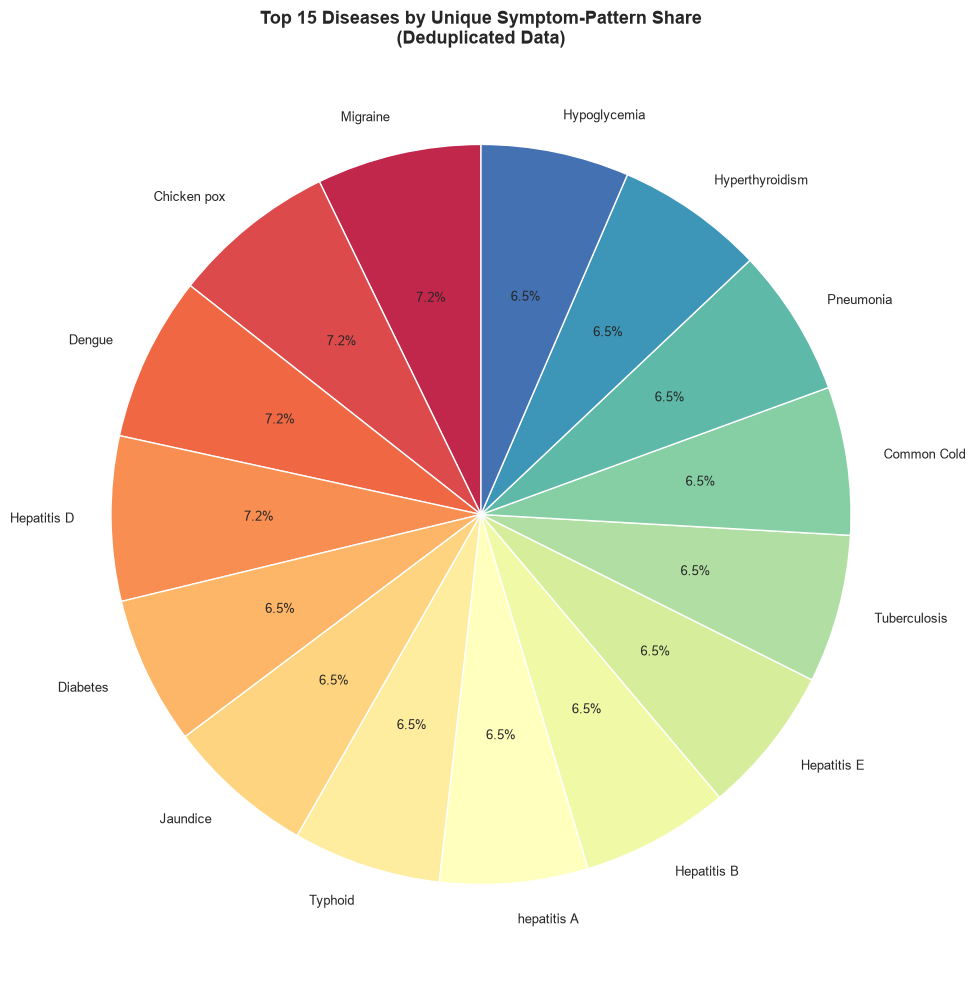

In [18]:
dedup_counts = train_dedup['prognosis'].value_counts().head(15)

plt.figure(figsize=(10, 10))
colors = sns.color_palette('Spectral', len(dedup_counts))
plt.pie(dedup_counts.values, labels=dedup_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 9})
plt.title('Top 15 Diseases by Unique Symptom-Pattern Share\n(Deduplicated Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.5 Symptom Word Cloud
Visualizes the most prominent symptom keywords across the entire dataset, weighted by frequency.

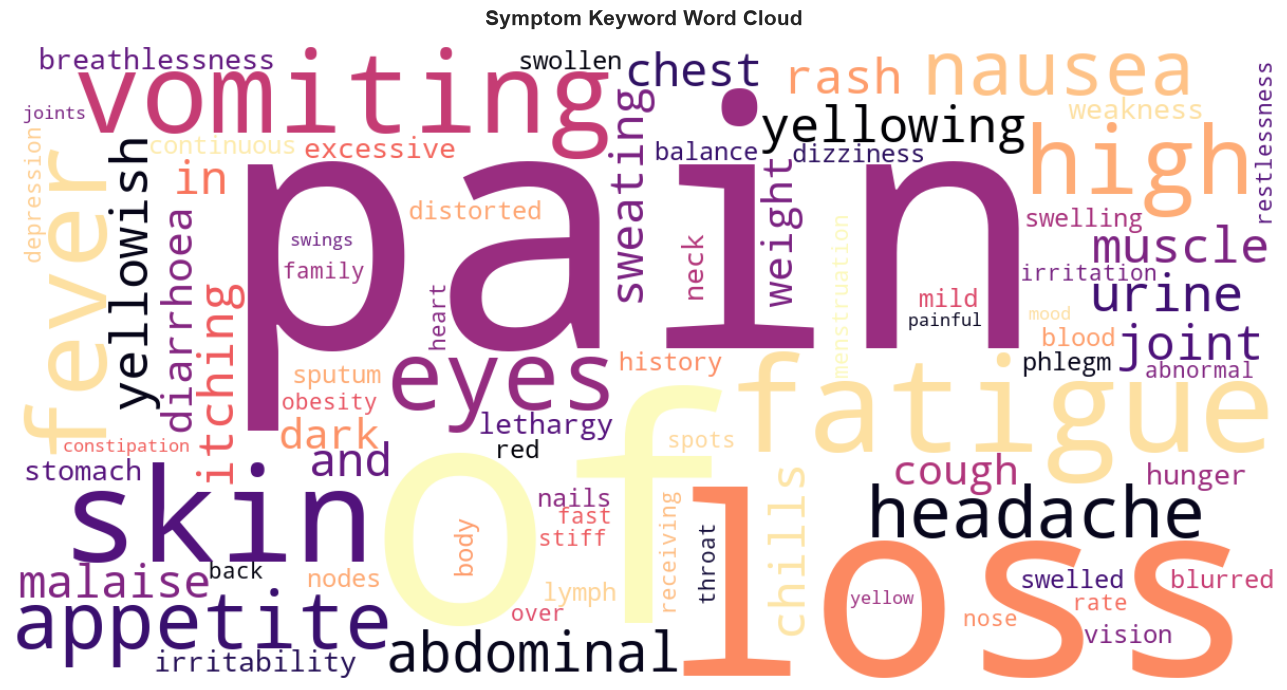

In [19]:
wc = WordCloud(width=1200, height=600, background_color='white',
                colormap='magma', max_words=80, collocations=False)
wc.generate_from_frequencies(word_freq.to_dict())

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Symptom Keyword Word Cloud', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### 7.6 Symptoms-per-Disease Distribution
How many symptoms, on average, characterise each disease — relevant for understanding model input sparsity in Ticket 2.

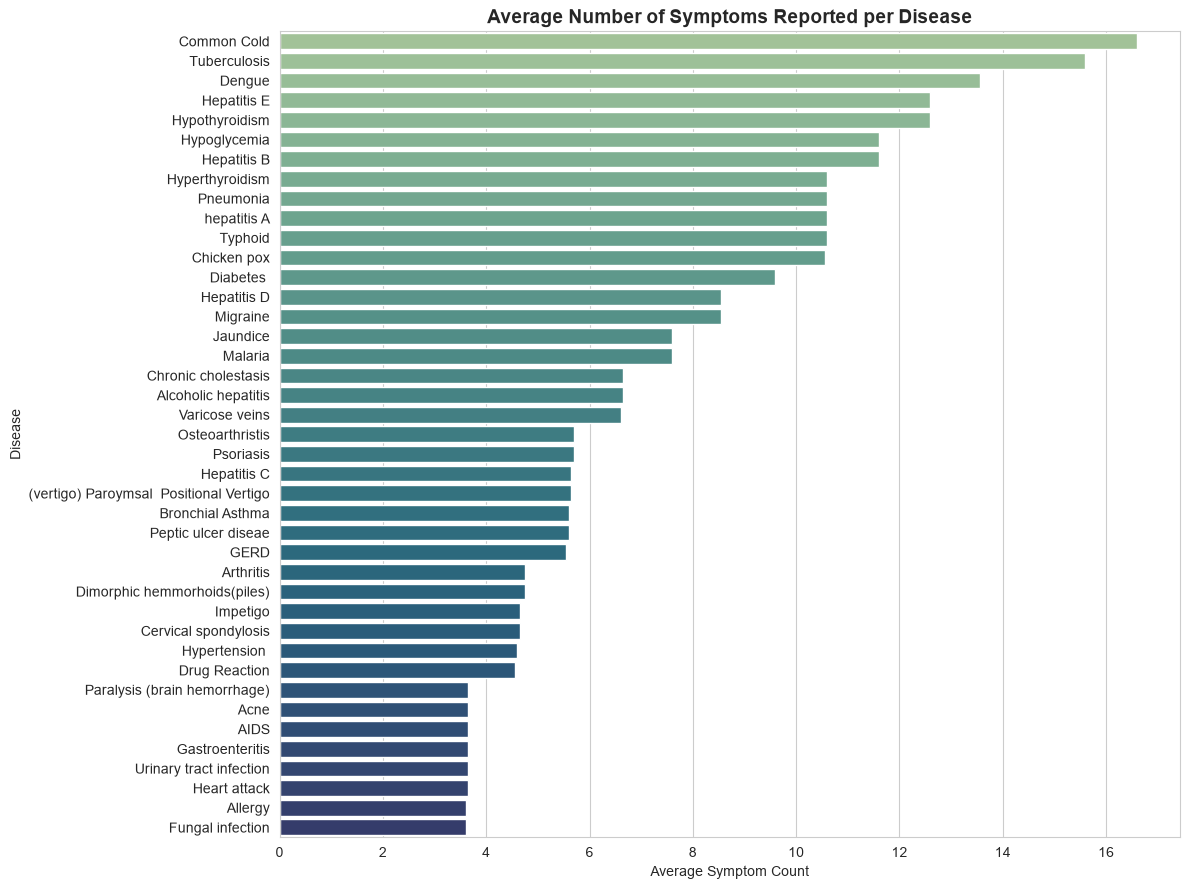

In [20]:
train_df['symptom_count'] = train_df[symptom_cols].sum(axis=1)
avg_symptoms = train_df.groupby('prognosis')['symptom_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 9))
sns.barplot(x=avg_symptoms.values, y=avg_symptoms.index, palette='crest')
plt.title('Average Number of Symptoms Reported per Disease', fontsize=14, fontweight='bold')
plt.xlabel('Average Symptom Count')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()


### 7.7 Symptom Severity Distribution
Using the supplementary severity-weight lookup table — relevant later for risk-level scoring in the Flask app (Ticket 3).

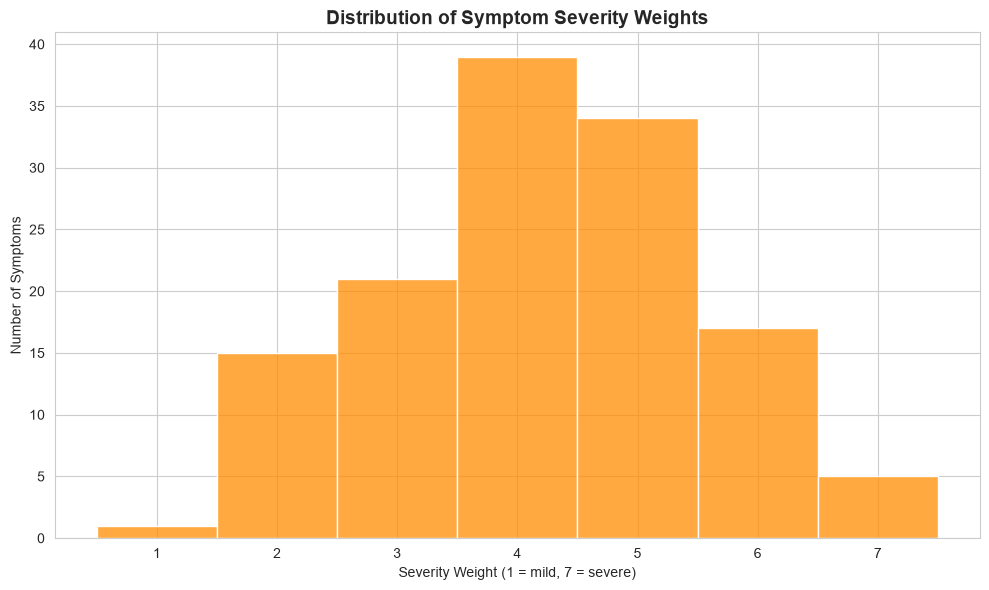

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(sev_df['weight'], bins=7, kde=False, color='darkorange', discrete=True)
plt.title('Distribution of Symptom Severity Weights', fontsize=14, fontweight='bold')
plt.xlabel('Severity Weight (1 = mild, 7 = severe)')
plt.ylabel('Number of Symptoms')
plt.tight_layout()
plt.show()


## 8. Summary of Key EDA Insights

- The raw training dataset contains **4,920 records across 41 diseases**, perfectly balanced at 120 rows per disease, but only **~304 unique symptom-combinations** remain after deduplication — Ticket 2 should benchmark models on both the full and deduplicated sets to check for overfitting risk on repeated rows.
- **132 binary symptom features** were validated as clean (no nulls, no invalid values) after removing one spurious trailing column from the raw export.
- High-frequency symptoms such as **fatigue, vomiting, high fever, and headache** appear across many disease classes, indicating some features alone carry low discriminative power and benefit from being considered in combination (supports using ensemble tree-based models in Ticket 2).
- The symptom co-occurrence heatmap shows clusters of correlated symptoms (e.g. gastrointestinal symptoms cluster together, respiratory symptoms cluster together), which can guide feature grouping or dimensionality reduction if needed.
- The number of symptoms per disease record ranges noticeably by condition, with some diseases (e.g. **AIDS, Hepatitis-family**) presenting fewer, more specific symptoms, while others (e.g. **Gastroenteritis, Typhoid**) present a broader symptom cluster.
- Supplementary lookup tables (`symptom_Description.csv`, `symptom_precaution.csv`, `Symptom-severity.csv`) were fully mapped to all 41 diseases and 132 symptoms, and are ready to enrich the GenAI recipe-recommendation prompt layer in Ticket 2.

## 9. Outputs Produced for Ticket 2

| File | Description |
|---|---|
| `data/Training_cleaned.csv` | Full cleaned training set (4,920 rows) with label encoding and symptom_text column |
| `data/Training_dedup.csv` | Deduplicated training set (304 unique rows) for overfitting comparison |
| `data/Testing_cleaned.csv` | Cleaned test set (42 rows) |
| `data/disease_label_mapping.csv` | LabelEncoder class-to-integer mapping |
| `data/symptom_Description.csv` | Disease descriptions (41 diseases) |
| `data/symptom_precaution.csv` | Precautions per disease (41 diseases x 4 precautions) |
| `data/Symptom-severity.csv` | Severity weight per symptom (132 symptoms) |


In [22]:
train_df.drop(columns=["symptom_count"]).to_csv(
    DATA_DIR / "Training_cleaned.csv",
    index=False
)

train_dedup.to_csv(
    DATA_DIR / "Training_dedup.csv",
    index=False
)

test_df.to_csv(
    DATA_DIR / "Testing_cleaned.csv",
    index=False
)

print("All cleaned datasets saved to /data/")


All cleaned datasets saved to /data/
